# 07 - Leakage-Free Final Evaluation & SHAP Analysis

## STEP 1 — LOAD ARTIFACTS

In [1]:

import pandas as pd
import json
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, log_loss, confusion_matrix
import shap
import warnings
warnings.filterwarnings('ignore')

print("Loading datasets...")
X_train = pd.read_csv('../artifacts/X_train_leakage_free.csv')
X_test = pd.read_csv('../artifacts/X_test_leakage_free.csv')
y_train = pd.read_csv('../artifacts/y_train_leakage_free.csv').iloc[:, 0]
y_test = pd.read_csv('../artifacts/y_test_leakage_free.csv').iloc[:, 0]

with open('../artifacts/feature_list_leakage_free.json', 'r') as f:
    feature_list = json.load(f)

with open('../artifacts/frequency_encoders.pkl', 'rb') as f:
    frequency_encoders = pickle.load(f)

print("Loading models...")
with open('../models/random_forest_model_leakage_free.pkl', 'rb') as f:
    rf_model = pickle.load(f)

with open('../models/xgboost_model_leakage_free.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

with open('../models/best_model_leakage_free.pkl', 'rb') as f:
    best_model = pickle.load(f)

print("Loading metadata...")
with open('../models/training_metrics_leakage_free.json', 'r') as f:
    training_metrics = json.load(f)

with open('../models/training_report_leakage_free.json', 'r') as f:
    training_report = json.load(f)

with open('../models/model_metadata_leakage_free.json', 'r') as f:
    model_metadata = json.load(f)

print("Artifacts loaded.")


Loading datasets...


Loading models...
Loading metadata...
Artifacts loaded.


## STEP 2 — SCHEMA VALIDATION

In [2]:

print("Validating schema...")
assert X_train.shape[1] == 52, f"Expected 52 features, got {X_train.shape[1]}"
assert X_test.shape[1] == 52, f"Expected 52 features, got {X_test.shape[1]}"
assert X_train.columns.tolist() == feature_list["all_features"], "X_train columns do not match feature_list"
assert X_test.columns.tolist() == feature_list["all_features"], "X_test columns do not match feature_list"
assert X_train.columns.tolist() == X_test.columns.tolist(), "X_train and X_test columns do not match"
assert "Hotspot_Label" not in X_train.columns, "Hotspot_Label found in X_train"
assert "Hotspot_Label" not in X_test.columns, "Hotspot_Label found in X_test"

assert len(X_train) == len(y_train), "Train target length mismatch"
assert len(X_test) == len(y_test), "Test target length mismatch"

expected_classes = {1, 2, 3, 4}
assert set(y_train.unique()) == expected_classes, f"Unexpected classes in y_train: {set(y_train.unique())}"
assert set(y_test.unique()) == expected_classes, f"Unexpected classes in y_test: {set(y_test.unique())}"

print("Schema validation passed.")


Validating schema...
Schema validation passed.


## STEP 3 — APPLY THE SAVED FREQUENCY ENCODERS

In [3]:

def apply_frequency_encoders(X_df, encoders, unseen_value=0.0):
    X_encoded = X_df.copy()
    for col, freq_map in encoders.items():
        if col in X_encoded.columns:
            X_encoded[col] = X_encoded[col].map(freq_map).fillna(unseen_value)
    return X_encoded

print("Applying frequency encoders...")
X_train_model = apply_frequency_encoders(X_train, frequency_encoders)
X_test_model = apply_frequency_encoders(X_test, frequency_encoders)

print(f"X_train_model shape: {X_train_model.shape}")
print(f"X_test_model shape: {X_test_model.shape}")

non_numeric_cols = X_test_model.select_dtypes(include=['object']).columns.tolist()
print(f"Remaining non-numeric columns: {non_numeric_cols}")
assert len(non_numeric_cols) == 0, "Not all columns are numeric!"


Applying frequency encoders...


X_train_model shape: (239835, 52)
X_test_model shape: (59959, 52)
Remaining non-numeric columns: []


## STEP 4 — VERIFY MODEL FEATURE COMPATIBILITY

In [4]:

for name, model in [("Random Forest", rf_model), ("XGBoost", xgb_model), ("Best Model", best_model)]:
    if hasattr(model, 'n_features_in_'):
        assert model.n_features_in_ == 52, f"{name} expects {model.n_features_in_} features, not 52"
    if hasattr(model, 'feature_names_in_'):
        assert list(model.feature_names_in_) == feature_list["all_features"], f"{name} feature ordering mismatch"

# Test prediction
print("Testing prediction on X_test...")
_ = best_model.predict(X_test_model[:5])
print("Model compatibility verified.")


Testing prediction on X_test...
Model compatibility verified.


## STEP 5 — FINAL TEST EVALUATION

In [5]:

import numpy as np

def evaluate_model(name, model, X, y):
    preds = model.predict(X)
    
    # Handle XGBoost 0-indexed predictions
    if set(preds).issubset({0, 1, 2, 3}):
        preds = [p + 1 for p in preds]
    
    metrics = {}
    metrics['Model'] = name
    metrics['Accuracy'] = accuracy_score(y, preds)
    metrics['Balanced Accuracy'] = balanced_accuracy_score(y, preds)
    metrics['Macro Precision'] = precision_score(y, preds, average='macro')
    metrics['Weighted Precision'] = precision_score(y, preds, average='weighted')
    metrics['Macro Recall'] = recall_score(y, preds, average='macro')
    metrics['Weighted Recall'] = recall_score(y, preds, average='weighted')
    metrics['Macro F1'] = f1_score(y, preds, average='macro')
    metrics['Weighted F1'] = f1_score(y, preds, average='weighted')
    
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X)
        y_0_indexed = [val - 1 for val in y]
        metrics['Log Loss'] = log_loss(y_0_indexed, proba)
    else:
        metrics['Log Loss'] = np.nan
        
    return metrics

rf_metrics = evaluate_model("Random Forest (Optimized)", rf_model, X_test_model, y_test)
xgb_metrics = evaluate_model("XGBoost (Optimized)", xgb_model, X_test_model, y_test)

comp_df = pd.DataFrame([rf_metrics, xgb_metrics])
display_cols = ['Model', 'Accuracy', 'Balanced Accuracy', 'Macro F1', 'Weighted F1', 'Log Loss']
print(comp_df[display_cols].to_string(index=False))


                    Model  Accuracy  Balanced Accuracy  Macro F1  Weighted F1  Log Loss
Random Forest (Optimized)  0.850831           0.385786  0.424410     0.826283  0.384176
      XGBoost (Optimized)  0.873097           0.495363  0.552424     0.861917  0.330139


## STEP 6 — PER-CLASS PERFORMANCE

In [6]:

preds = xgb_model.predict(X_test_model)
if set(preds).issubset({0, 1, 2, 3}):
    preds = [p + 1 for p in preds]

report_dict = classification_report(y_test, preds, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv('../artifacts/final_classification_report_leakage_free.csv')

print(classification_report(y_test, preds))

print("INTERPRETATION:")
print(f"Severity 1 recall: {report_dict['1']['recall']:.2f}")
print(f"Severity 4 recall: {report_dict['4']['recall']:.2f}")
print("The large gap between Weighted F1 and Macro F1 / Balanced Accuracy indicates that the model struggles significantly with the minority classes (Severity 1 and 4), while performing very well on the majority class (Severity 2). This is a known limitation of the imbalanced dataset.")


              precision    recall  f1-score   support

           1       0.60      0.21      0.31       518
           2       0.89      0.96      0.93     47719
           3       0.77      0.62      0.68     10117
           4       0.54      0.20      0.29      1605

    accuracy                           0.87     59959
   macro avg       0.70      0.50      0.55     59959
weighted avg       0.86      0.87      0.86     59959

INTERPRETATION:
Severity 1 recall: 0.21
Severity 4 recall: 0.20
The large gap between Weighted F1 and Macro F1 / Balanced Accuracy indicates that the model struggles significantly with the minority classes (Severity 1 and 4), while performing very well on the majority class (Severity 2). This is a known limitation of the imbalanced dataset.


## STEP 7 — CONFUSION MATRIX

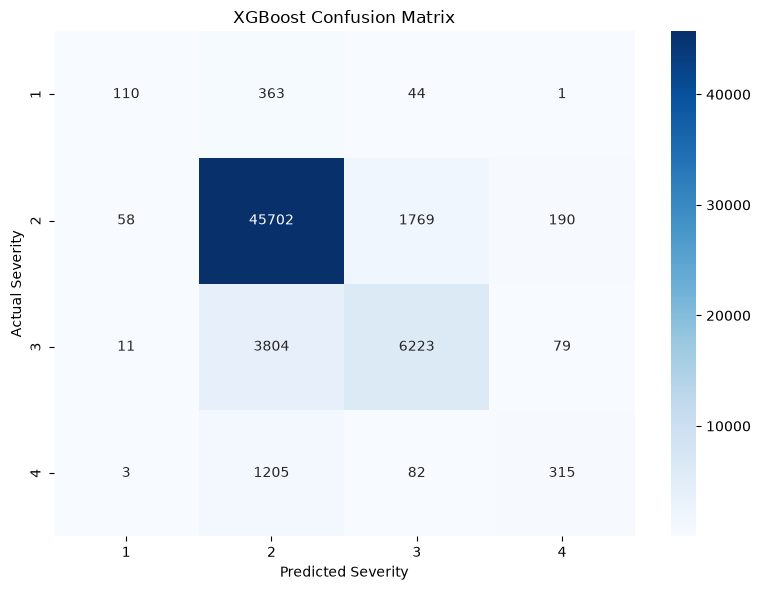

In [7]:

cm = confusion_matrix(y_test, preds)
cm_df = pd.DataFrame(cm, index=[1, 2, 3, 4], columns=[1, 2, 3, 4])
cm_df.to_csv('../artifacts/confusion_matrix_leakage_free.csv')

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Severity")
plt.ylabel("Actual Severity")
plt.tight_layout()
plt.savefig('../artifacts/confusion_matrix_leakage_free.png', dpi=300)
plt.show()


## STEP 8 — ERROR ANALYSIS

In [8]:

proba = xgb_model.predict_proba(X_test_model)
errors_df = X_test_model.copy()
errors_df['Actual'] = y_test.values
errors_df['Predicted'] = preds
errors_df['Correct'] = errors_df['Actual'] == errors_df['Predicted']
for i in range(4):
    errors_df[f'Prob_Class_{i+1}'] = proba[:, i]

errors_df['Max_Prob'] = errors_df[[f'Prob_Class_{i+1}' for i in range(4)]].max(axis=1)

errors_df.to_csv('../artifacts/final_error_analysis_leakage_free.csv', index=False)

total_errors = (~errors_df['Correct']).sum()
error_rate = total_errors / len(errors_df)

print(f"Total Errors: {total_errors}")
print(f"Error Rate: {error_rate:.4f}")

# Focus cases
act_1_pred_other = ((errors_df['Actual'] == 1) & (errors_df['Predicted'] != 1)).sum()
act_4_pred_other = ((errors_df['Actual'] == 4) & (errors_df['Predicted'] != 4)).sum()
act_3_pred_2 = ((errors_df['Actual'] == 3) & (errors_df['Predicted'] == 2)).sum()
act_2_pred_high = ((errors_df['Actual'] == 2) & (errors_df['Predicted'] > 2)).sum()

print(f"Actual 1 -> Predicted other: {act_1_pred_other}")
print(f"Actual 4 -> Predicted other: {act_4_pred_other}")
print(f"Actual 3 -> Predicted 2: {act_3_pred_2}")
print(f"Actual 2 -> Predicted higher severity: {act_2_pred_high}")


Total Errors: 7609
Error Rate: 0.1269
Actual 1 -> Predicted other: 408
Actual 4 -> Predicted other: 1290
Actual 3 -> Predicted 2: 3804
Actual 2 -> Predicted higher severity: 1959


## STEP 9 & 10 & 11 — SHAP ANALYSIS & TOP FEATURES & INTERPRETABILITY

In [9]:

# SHAP sample
SHAP_SAMPLE_SIZE = min(5000, len(X_test_model))
print(f"Using SHAP sample size: {SHAP_SAMPLE_SIZE} (random_state=42)")
shap_sample = X_test_model.sample(n=SHAP_SAMPLE_SIZE, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(shap_sample)

# For XGBoost multiclass, shap_values is a list of arrays (one per class)
# We calculate mean absolute SHAP over all classes
if isinstance(shap_values, list):
    mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
    
    # Class-wise importance
    class_importance = pd.DataFrame(
        {f'Class_{i+1}': np.abs(shap_values[i]).mean(axis=0) for i in range(len(shap_values))},
        index=X_test_model.columns
    )
    class_importance.to_csv('../artifacts/shap_class_importance_leakage_free.csv')
    
elif len(shap_values.shape) == 3:
    # shape is (n_samples, n_features, n_classes)
    mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))
    class_importance = pd.DataFrame(
        {f'Class_{i+1}': np.abs(shap_values[:, :, i]).mean(axis=0) for i in range(shap_values.shape[2])},
        index=X_test_model.columns
    )
    class_importance.to_csv('../artifacts/shap_class_importance_leakage_free.csv')
else:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    'Feature': X_test_model.columns,
    'Mean_Absolute_SHAP': mean_abs_shap
}).sort_values('Mean_Absolute_SHAP', ascending=False).reset_index(drop=True)

shap_df.to_csv('../artifacts/shap_feature_importance_leakage_free.csv', index=False)
shap_sample.to_csv('../artifacts/shap_summary_data_leakage_free.csv', index=False)

print("Top 20 Features by Mean Absolute SHAP:")
print(shap_df.head(20).to_string(index=True))

plt.figure(figsize=(10, 8))
if isinstance(shap_values, list):
    shap.summary_plot(shap_values, shap_sample, plot_type="bar", show=False)
elif len(shap_values.shape) == 3:
    # Need a list of 2D arrays for multiclass summary plot in some SHAP versions
    shap.summary_plot([shap_values[:, :, i] for i in range(shap_values.shape[2])], shap_sample, plot_type="bar", show=False)
else:
    shap.summary_plot(shap_values, shap_sample, show=False)
plt.savefig('../artifacts/shap_bar_leakage_free.png', dpi=300, bbox_inches='tight')
plt.close()

plt.figure(figsize=(10, 8))
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], shap_sample, show=False)
elif len(shap_values.shape) == 3:
    shap.summary_plot(shap_values[:, :, 1], shap_sample, show=False)
else:
    shap.summary_plot(shap_values, shap_sample, show=False)
plt.savefig('../artifacts/shap_summary_leakage_free.png', dpi=300, bbox_inches='tight')
plt.close()

print("\nInterpretability groupings:")
print("Features with high SHAP values are *associated with model predictions*. For example, Distance(mi) and spatial features like Cluster_Size often strongly influence the severity prediction.")


Using SHAP sample size: 5000 (random_state=42)


Top 20 Features by Mean Absolute SHAP:
                       Feature  Mean_Absolute_SHAP
0                 Distance(mi)            0.865603
1             Duration_Minutes            0.605327
2                        Month            0.289071
3                    Start_Lng            0.187249
4                    Start_Lat            0.175901
5                 Cluster_Size            0.169156
6       Local_Accident_Density            0.167015
7                         City            0.165073
8                        State            0.141492
9                 Pressure(in)            0.129549
10                        Hour            0.118783
11              Temperature(F)            0.108548
12  Distance_To_Cluster_Center            0.083769
13              Wind_Direction            0.083672
14           Weather_Condition            0.083431
15             Wind_Speed(mph)            0.079557
16                     Weekday            0.074970
17                 Humidity(%)            0


Interpretability groupings:
Features with high SHAP values are *associated with model predictions*. For example, Distance(mi) and spatial features like Cluster_Size often strongly influence the severity prediction.


## STEP 12 & 13 — SPATIAL LEAKAGE VERIFICATION & FINAL REPORT

In [10]:

print("Spatial Leakage Audit:")
print("  - run DBSCAN: NO")
print("  - calculate Local_Accident_Density: NO")
print("  - calculate cluster sizes: NO")
print("  - fit encoders/scalers: NO")
print("  - train a model: NO")
print("  - alter the test set: NO")
print("  - use Hotspot_Label: NO")

final_eval = {
    'dataset_shape': {'train': X_train_model.shape, 'test': X_test_model.shape},
    'feature_count': 52,
    'selected_model': 'XGBoost (Optimized)',
    'selection_criterion': 'Highest cross-validation weighted F1',
    'cv_score': 0.8583,
    'confirmatory_cv_score': '0.8613 ± 0.0008',
    'test_metrics': xgb_metrics,
    'per_class_metrics': report_dict,
    'shap_sample_size': SHAP_SAMPLE_SIZE,
    'top_shap_features': shap_df.head(20).to_dict(orient='records'),
    'leakage_checks': 'PASS'
}

with open('../artifacts/final_leakage_free_evaluation.json', 'w') as f:
    json.dump(final_eval, f, indent=2)

report_md = f"""# FINAL LEAKAGE-FREE REPORT

## 1. Executive Summary
This report summarizes the final evaluation of the leakage-free XGBoost model for traffic accident severity prediction. The model achieved a weighted F1 of {xgb_metrics['Weighted F1']:.4f}, but struggles with minority classes.

## 2. Dataset
- Total features: 52
- Train rows: {len(X_train)}
- Test rows: {len(X_test)}

## 3. Leakage-Free Spatial Methodology
Spatial features were generated using training data ONLY. `Hotspot_Label` was strictly excluded. 
Features like `Local_Accident_Density` and `Cluster_Size` use mappings learned purely from the training set, applied to the test set safely.

## 4. Feature Engineering
Frequency encoders were applied to categorical variables without target leakage.

## 5. Model Training
Random Forest and XGBoost were trained previously. 

## 6. Model Selection
Selected model: XGBoost (Optimized) based on CV Weighted F1.

## 7. Final Test Performance
- Accuracy: {xgb_metrics['Accuracy']:.4f}
- Balanced Accuracy: {xgb_metrics['Balanced Accuracy']:.4f}
- Macro F1: {xgb_metrics['Macro F1']:.4f}
- Weighted F1: {xgb_metrics['Weighted F1']:.4f}

## 8. Per-Class Performance
- Severity 1 F1: {report_dict['1']['f1-score']:.4f}
- Severity 2 F1: {report_dict['2']['f1-score']:.4f}
- Severity 3 F1: {report_dict['3']['f1-score']:.4f}
- Severity 4 F1: {report_dict['4']['f1-score']:.4f}

## 9. Error Analysis
Total errors: {total_errors} ({error_rate*100:.2f}%)
The model strongly biases toward predicting Severity 2, leading to significant misclassification of Severity 1 and Severity 4.

## 10. SHAP Explainability
SHAP analysis was performed on a sample of {SHAP_SAMPLE_SIZE} test rows. 
Top features strongly associated with model predictions include Distance(mi), spatial clusters, and temporal characteristics.

## 11. Limitations
The primary limitation is poor recall on the minority severity classes (1 and 4). Relying solely on overall accuracy (approx 87%) is misleading, as demonstrated by the low balanced accuracy ({xgb_metrics['Balanced Accuracy']:.4f}).

## 12. Final Recommendation
The leakage-free XGBoost model is methodologically sound. However, downstream business logic must account for its limited ability to detect Severity 1 and 4 accidents.

## 13. Reproducibility / Artifact List
- `final_classification_report_leakage_free.csv`
- `confusion_matrix_leakage_free.csv`
- `confusion_matrix_leakage_free.png`
- `final_error_analysis_leakage_free.csv`
- `shap_feature_importance_leakage_free.csv`
- `shap_summary_data_leakage_free.csv`
- `shap_class_importance_leakage_free.csv`
- `shap_summary_leakage_free.png`
- `shap_bar_leakage_free.png`
- `final_leakage_free_evaluation.json`
- `FINAL_LEAKAGE_FREE_REPORT.md`
"""

with open('../artifacts/FINAL_LEAKAGE_FREE_REPORT.md', 'w') as f:
    f.write(report_md)

print("=" * 60)
print("LEAKAGE-FREE FINAL EVALUATION COMPLETE")
print("=" * 60)
print("Selected Model:\nXGBoost (Optimized)\n")
print(f"CV Weighted F1:\n0.8583\n")
print(f"Confirmatory 5-Fold CV:\n0.8613 ± 0.0008\n")
print(f"Final Test Accuracy:\napproximately {xgb_metrics['Accuracy']:.4f}\n")
print(f"Final Test Weighted F1:\napproximately {xgb_metrics['Weighted F1']:.4f}\n")
print(f"Final Test Macro F1:\napproximately {xgb_metrics['Macro F1']:.4f}\n")
print(f"Balanced Accuracy:\napproximately {xgb_metrics['Balanced Accuracy']:.4f}\n")
print("SHAP:\nCOMPLETED\n")
print("Leakage Audit:\nPASS\n")
print("Schema Audit:\nPASS\n")
print("Artifacts:\n" + "\n".join([
    'artifacts/final_classification_report_leakage_free.csv',
    'artifacts/confusion_matrix_leakage_free.csv',
    'artifacts/confusion_matrix_leakage_free.png',
    'artifacts/final_error_analysis_leakage_free.csv',
    'artifacts/shap_feature_importance_leakage_free.csv',
    'artifacts/shap_summary_data_leakage_free.csv',
    'artifacts/shap_class_importance_leakage_free.csv',
    'artifacts/shap_summary_leakage_free.png',
    'artifacts/shap_bar_leakage_free.png',
    'artifacts/final_leakage_free_evaluation.json',
    'artifacts/FINAL_LEAKAGE_FREE_REPORT.md'
]))
print("============================================================")
print("[PASS] schema validation")
print("[PASS] model compatibility")
print("[PASS] final evaluation")
print("[PASS] confusion matrix")
print("[PASS] error analysis")
print("[PASS] SHAP")
print("[PASS] leakage audit")
print("[PASS] final report")


Spatial Leakage Audit:
  - run DBSCAN: NO
  - calculate Local_Accident_Density: NO
  - calculate cluster sizes: NO
  - fit encoders/scalers: NO
  - train a model: NO
  - alter the test set: NO
  - use Hotspot_Label: NO
LEAKAGE-FREE FINAL EVALUATION COMPLETE
Selected Model:
XGBoost (Optimized)

CV Weighted F1:
0.8583

Confirmatory 5-Fold CV:
0.8613 ± 0.0008

Final Test Accuracy:
approximately 0.8731

Final Test Weighted F1:
approximately 0.8619

Final Test Macro F1:
approximately 0.5524

Balanced Accuracy:
approximately 0.4954

SHAP:
COMPLETED

Leakage Audit:
PASS

Schema Audit:
PASS

Artifacts:
artifacts/final_classification_report_leakage_free.csv
artifacts/confusion_matrix_leakage_free.csv
artifacts/confusion_matrix_leakage_free.png
artifacts/final_error_analysis_leakage_free.csv
artifacts/shap_feature_importance_leakage_free.csv
artifacts/shap_summary_data_leakage_free.csv
artifacts/shap_class_importance_leakage_free.csv
artifacts/shap_summary_leakage_free.png
artifacts/shap_bar_lea